In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
import PIL
import random
import seaborn as sns
from pathlib import Path
import cv2
import pandas as pd


In [2]:
# Set random seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed}")

set_seed(42)

# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define paths
DATA_ROOT = r"D:\Uni\Lab\inebriation-voice-detector\data\processed"
TRAIN_DIR = os.path.join(DATA_ROOT,'ex_val',  "TRAIN")
VAL_DIR = os.path.join(DATA_ROOT,'ex_val', "VAL")
TEST_DIR = os.path.join(DATA_ROOT,'ex_val',  "TEST")

# Create output directory
OUTPUT_ROOT = r"D:\Uni\Lab\inebriation-voice-detector\output"
OUTPUT_DIR =os.path.join(OUTPUT_ROOT, "resnet18")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Define class labels
classes = ['SOBER', 'DRUNK']
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for idx, cls in enumerate(classes)}
print(idx_to_class)
print(class_to_idx)


Random seed set to 42
Using device: cuda:0
{0: 'SOBER', 1: 'DRUNK'}
{'SOBER': 0, 'DRUNK': 1}


## Data Exploration

In [3]:


def explore_dataset(data_dir, title):
    """Explore the dataset and visualize class distribution."""
    class_counts = {cls: 0 for cls in classes}
    file_paths = []
    labels = []
    
    for class_name in classes:
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png'))]
            class_counts[class_name] = len(files)
            
            for file in files:
                file_paths.append(os.path.join(class_path, file))
                labels.append(class_to_idx[class_name])
    
    # Print statistics
    print(f"\n{title} Dataset Statistics:")
    for cls, count in class_counts.items():
        print(f"  {cls}: {count} samples")
    print(f"  Total: {sum(class_counts.values())} samples")
    
    # Plot class distribution
    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
    plt.title(f"{title} Dataset Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Number of Samples")
    for i, count in enumerate(class_counts.values()):
        plt.text(i, count + 5, str(count), ha='center')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{title.lower()}_class_distribution.png"))
    plt.close()
    
    return file_paths, labels, class_counts

# Explore all datasets
train_files, train_labels, train_counts = explore_dataset(TRAIN_DIR, "Training")
val_files, val_labels, val_counts = explore_dataset(VAL_DIR, "Validation")
test_files, test_labels, test_counts = explore_dataset(TEST_DIR, "Test")


Training Dataset Statistics:
  SOBER: 7300 samples
  DRUNK: 3168 samples
  Total: 10468 samples

Validation Dataset Statistics:
  SOBER: 1630 samples
  DRUNK: 686 samples
  Total: 2316 samples

Test Dataset Statistics:
  SOBER: 2187 samples
  DRUNK: 1858 samples
  Total: 4045 samples


## Data Visualization

In [4]:


def visualize_spectrograms(file_paths, labels, num_samples=5, save_path=None):
    """Visualize sample spectrograms from each class"""
    # Get sample images from each class
    samples_by_class = {cls: [] for cls in classes}
    for path, label in zip(file_paths, labels):
        class_name = idx_to_class[label]
        if len(samples_by_class[class_name]) < num_samples:
            samples_by_class[class_name].append(path)
    
    # Create subplot grid
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(15, 5))
    
    for i, class_name in enumerate(classes):
        for j, img_path in enumerate(samples_by_class[class_name]):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{class_name}")
            axes[i, j].axis('off')
    
    plt.suptitle("Sample Spectrogram Images")
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    plt.close()

# Visualize sample spectrograms
visualize_spectrograms(
    train_files, 
    train_labels, 
    num_samples=5, 
    save_path=os.path.join(OUTPUT_DIR, "sample_spectrograms.png")
)

## Dataset 

In [5]:

class SpectrogramDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['SOBER', 'DRUNK']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.samples = self._make_dataset()
        
    def _make_dataset(self):
        samples = []
        for class_name in os.listdir(self.root_dir):
            class_path = os.path.join(self.root_dir, class_name)
            if os.path.isdir(class_path):
                class_idx = self.class_to_idx[class_name]
                for filename in os.listdir(class_path):
                    if filename.endswith(('.jpg', '.jpeg', '.png')):
                        samples.append((
                            os.path.join(class_path, filename),
                            class_idx
                        ))
        return samples
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label, img_path



## Data Preparation

In [6]:

# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def custom_collate_fn(batch):
    images, labels, paths = zip(*batch)
    images = torch.stack(images, dim=0)
    labels = torch.tensor(labels)
    return images, labels, paths

# Initialize datasets

train_dataset = SpectrogramDataset(TRAIN_DIR, transform)
val_dataset = SpectrogramDataset(VAL_DIR, transform)
test_dataset = SpectrogramDataset(TEST_DIR, transform)

# Create balanced sampler
class_counts = torch.tensor([len([x for x in train_dataset.samples if x[1] == i]) for i in range(2)])
class_weights = 1. / class_counts
class_weights = class_weights / class_weights.sum()  # Normalize
sample_weights = torch.tensor([class_weights[y] for _, y in train_dataset.samples])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# Create data loaders
BATCH_SIZE = 100
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    sampler=sampler, 
    collate_fn=custom_collate_fn
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=custom_collate_fn
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=custom_collate_fn
)


## Model

In [ ]:
def resnet18_classifier():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze deeper layers for fine-tuning
    for param in model.layer3.parameters():
        param.requires_grad = True
    model.layer3.add_module('dropout', nn.Dropout(0.3))
    for param in model.layer4.parameters():
        param.requires_grad = True
    model.layer4.add_module('dropout', nn.Dropout(0.3))

    # Replace classifier head
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, 1)  # Output for binary classification
    )

    return model.to(device)



## Training Set Up

In [ ]:

model = resnet18_classifier()
initial_lr =1e-4 # 1e-4 #3e-4  # Start with a very small lr
patience = 5   # Early stopping patience
num_epochs =15
weight_decay = 1e-4

# Use class distribution from training data to set pos_weight
# train_counts = {'SOBER': 5189, 'DRUNK': 2281}
pos_weight = torch.tensor([train_counts['SOBER'] / train_counts['DRUNK']]).to(device)
#pos_weight = torch.tensor(2).to(device)

# Use BCEWithLogitsLoss with pos_weight to handle imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
#criterion = nn.BCEWithLogitsLoss()

# Optimizer for fine-tuned layers only
# optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, weight_decay=1e-4)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=initial_lr , weight_decay=weight_decay)


# Learning rate scheduler — Reduce on plateau (e.g., validation loss)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=patience, factor=0.5)


print("\nTraining setup:")
print("Model: ResNet18 pretrained")
print(f"Using initial_lr = {initial_lr} and weight_decay = {weight_decay}")
print("LR scheduler: ReduceLROnPlateau (on val loss)")
print(f"Using pos_weight = {pos_weight.item():.4f}")


Training setup:
Model: ResNet18 pretrained
Using initial_lr = 0.0003 and weight_decay = 0.0001
LR scheduler: ReduceLROnPlateau (on val loss)
Using pos_weight = 2.3043


In [9]:


# Evaluation Function
def evaluate(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    running_loss = 0.0
    
    with torch.no_grad():
        for inputs, labels, _ in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).float()
            
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            preds = (outputs >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Calculate UAR (Unweighted Average Recall)
    cm = confusion_matrix(all_labels, all_preds)
    if cm.shape == (2, 2):  # binary classification
        tn, fp, fn, tp = cm.ravel()
        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        uar = (tpr + tnr) / 2
    else:  # handle case when one class is missing in predictions
        uar = accuracy_score(all_labels, all_preds)  # fallback
    
    metrics = {
        'loss': running_loss / len(data_loader.dataset),
        'accuracy': accuracy_score(all_labels, all_preds),
        'uar': uar,
        'confusion_matrix': cm
    }
    
    return metrics

## Training


Epoch 1/10
----------


Training: 100%|██████████| 105/105 [01:12<00:00,  1.44it/s]


Train Loss: 0.8233 | Val Loss: 1.0275
Train Acc: 0.6967 | Val Acc: 0.6123
Train UAR: 0.6967 | Val UAR: 0.6249
Validation Confusion Matrix:
[[968 662]
 [236 450]]
Saved new best model (based on UAR)!

Epoch 2/10
----------


Training: 100%|██████████| 105/105 [00:39<00:00,  2.66it/s]


Train Loss: 0.4859 | Val Loss: 1.0865
Train Acc: 0.8617 | Val Acc: 0.6511
Train UAR: 0.8616 | Val UAR: 0.6833
Validation Confusion Matrix:
[[985 645]
 [163 523]]
Saved new best model (based on UAR)!

Epoch 3/10
----------


...

Train Loss: 0.0408 | Val Loss: 1.7299
Train Acc: 0.9897 | Val Acc: 0.7634
Train UAR: 0.9897 | Val UAR: 0.7078
Validation Confusion Matrix:
[[1376  254]
 [ 294  392]]
Saved new best model (based on UAR)!

Epoch 9/10
----------


Training: 100%|██████████| 105/105 [00:19<00:00,  5.44it/s]


Train Loss: 0.0125 | Val Loss: 1.9959
Train Acc: 0.9974 | Val Acc: 0.7608
Train UAR: 0.9974 | Val UAR: 0.6937
Validation Confusion Matrix:
[[1399  231]
 [ 323  363]]
No improvement in UAR for 1/5 epochs

Epoch 10/10
----------


Training: 100%|██████████| 105/105 [00:19<00:00,  5.47it/s]


Train Loss: 0.0061 | Val Loss: 2.0887
Train Acc: 0.9990 | Val Acc: 0.7513
Train UAR: 0.9990 | Val UAR: 0.6950
Validation Confusion Matrix:
[[1358  272]
 [ 304  382]]
No improvement in UAR for 2/5 epochs

Training completed. Loaded best model weights.


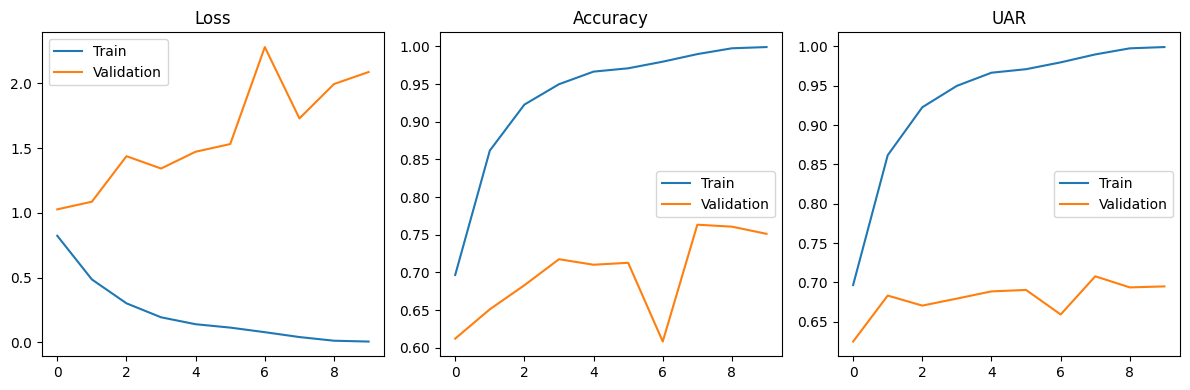

In [10]:
# Training Loop with Early Stopping
def train_model(model, train_loader, val_loader, num_epochs, patience):
    best_uar = 0
    no_improvement = 0
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_uar': [], 'val_uar': []
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 10)
        
        # Training phase
        model.train()
        train_loss = 0
        train_preds = []
        train_labels = []
        
        for inputs, labels,_ in tqdm(train_loader, desc="Training"):
            inputs, labels = inputs.to(device), labels.to(device).float()
            
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            preds = (outputs >= 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        
        # Calculate training metrics
        train_loss = train_loss / len(train_loader.dataset)
        train_acc = accuracy_score(train_labels, train_preds)
        
        # Calculate training UAR
        train_cm = confusion_matrix(train_labels, train_preds)
        if train_cm.shape == (2, 2):
            tn, fp, fn, tp = train_cm.ravel()
            tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
            train_uar = (tpr + tnr) / 2
        else:
            train_uar = train_acc
        
        # Validation phase
        val_metrics = evaluate(model, val_loader)
        
        # Update LR scheduler
        # scheduler.step()
        scheduler.step(val_metrics['loss'])
        
        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_metrics['accuracy'])
        history['train_uar'].append(train_uar)
        history['val_uar'].append(val_metrics['uar'])
        
        # Print metrics
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f}")
        print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_metrics['accuracy']:.4f}")
        print(f"Train UAR: {train_uar:.4f} | Val UAR: {val_metrics['uar']:.4f}")
        print("Validation Confusion Matrix:")
        print(val_metrics['confusion_matrix'])
        
        # Early stopping check
        if val_metrics['uar'] > best_uar:
            best_uar = val_metrics['uar']
            no_improvement = 0
            torch.save(model.state_dict(), os.path.join(OUTPUT_DIR,"best_model.pth"))
            print("Saved new best model (based on UAR)!")
        else:
            no_improvement += 1
            print(f"No improvement in UAR for {no_improvement}/{patience} epochs")
            
            if no_improvement >= patience:
                print(f"\nEarly stopping triggered after {patience} epochs without improvement!")
                break
    
    # Load the best model weights before returning
    model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR,"best_model.pth")) )
    print("\nTraining completed. Loaded best model weights.")
    
    return history

# Train the model with early stopping
history = train_model(
    model, 
    train_loader, 
    val_loader, 
    num_epochs,
    patience  # Stop if no improvement for 10 epochs
)


# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Train')
plt.plot(history['val_acc'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history['train_uar'], label='Train')
plt.plot(history['val_uar'], label='Validation')
plt.title('UAR')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"training_curves.png"))
plt.show()




## Evaluation


Final Test Results:
Accuracy: 0.6363
UAR: 0.6244
Confusion Matrix:
[[1686  501]
 [ 970  888]]


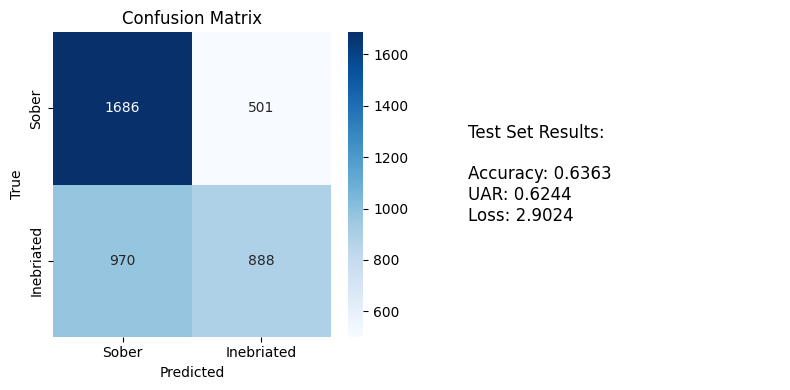

In [11]:
def plot_results(metrics, class_names):
    plt.figure(figsize=(8, 4))
    
    # Confusion matrix
    plt.subplot(1, 2, 1)
    sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', 
                cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    
    # Metrics summary
    plt.subplot(1, 2, 2)
    plt.axis('off')
    metrics_text = (
        "Test Set Results:\n\n"
        f"Accuracy: {metrics['accuracy']:.4f}\n"
        f"UAR: {metrics['uar']:.4f}\n"
        f"Loss: {metrics['loss']:.4f}\n"
    )
    plt.text(0.1, 0.5, metrics_text, fontsize=12, va='center')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,"test_results.png"))
    plt.show()

def get_detailed_predictions(model, data_loader, device='cuda'):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    all_filenames = []

    with torch.no_grad():
        for inputs, labels, paths in data_loader:  # assuming custom dataset returns file paths too
            inputs = inputs.to(device)
            labels = labels.to(device).float()

            outputs = model(inputs).squeeze()
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_filenames.extend([os.path.basename(p) for p in paths])

    return pd.DataFrame({
        'filename': all_filenames,
        'true_label': all_labels,
        'predicted_label': all_preds,
        'prob_drunk': all_probs,
        'prob_sober': 1 - np.array(all_probs),
        'correct': np.array(all_preds) == np.array(all_labels)
    })
     

# Load model and evaluate metrics
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "best_model.pth")))
test_metrics = evaluate(model, test_loader)

print("\nFinal Test Results:")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"UAR: {test_metrics['uar']:.4f}")
print("Confusion Matrix:")
print(test_metrics['confusion_matrix'])
plot_results(test_metrics, ['Sober', 'Inebriated'])

# Get per-sample predictions
df_preds = get_detailed_predictions(model, test_loader,device='cuda')
df_preds.to_csv(os.path.join(OUTPUT_DIR, "detailed_predictions.csv"), index=False)



In [12]:
df_preds.to_csv(os.path.join(OUTPUT_DIR, "detailed_predictions.csv"), index=False)

### Post processing error analysis

c:\Users\krevi\AppData\Local\anaconda3\envs\phonetics_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\krevi\AppData\Local\anaconda3\envs\phonetics_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\krevi\AppData\Local\anaconda3\envs\phonetics_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

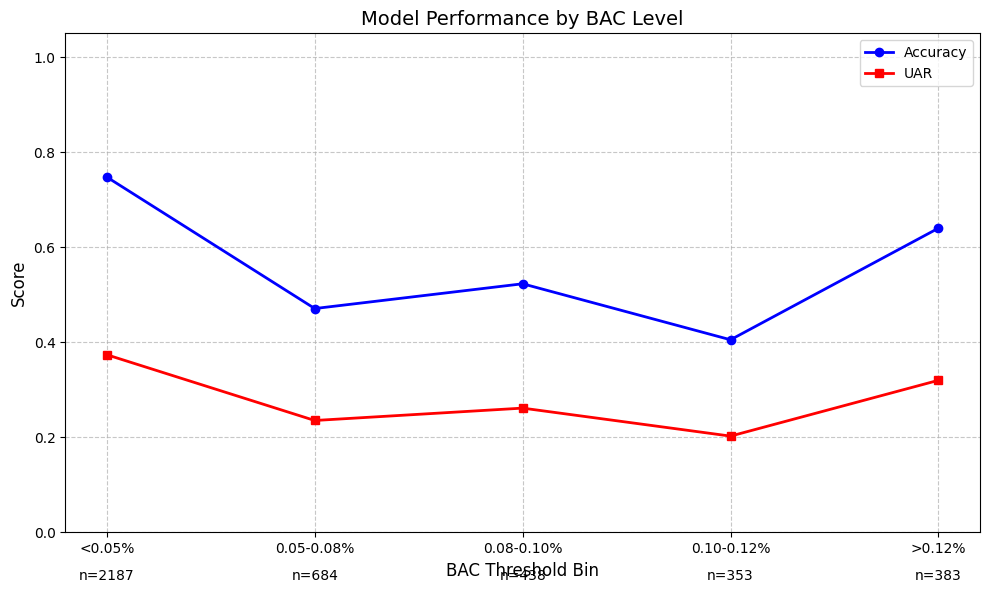

      BAC_bin  Accuracy       UAR  Count  bin_code
0      <0.05%  0.747142  0.373571   2187         0
1  0.05-0.08%  0.470760  0.235380    684         1
2  0.08-0.10%  0.522831  0.261416    438         2
3  0.10-0.12%  0.405099  0.202550    353         3
4      >0.12%  0.639687  0.319843    383         4


In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score


def analyze_performance_by_bac(preds_path, metadata_path):
    # Load and merge data
    preds = pd.read_csv(preds_path)
    meta = pd.read_csv(metadata_path)
    
    # Clean filenames
    preds['filename'] = preds['filename'].apply(lambda x: x.split('/')[-1])
    meta['filename'] = meta['spectrogram_fileP'].apply(lambda x: x.split('\\')[-1])
    
    # Merge datasets on cleaned filename
    df = pd.merge(preds, meta[['filename', 'BAC_level']], on='filename', how='inner')
    
    # Define BAC bins and labels
    bins = [0, 0.0005, 0.0008, 0.0010, 0.0012, float('inf')]
    labels = ['<0.05%', '0.05-0.08%', '0.08-0.10%', '0.10-0.12%', '>0.12%']
    df['BAC_bin'] = pd.cut(df['BAC_level'], bins=bins, labels=labels, right=False)
    
    # Prepare results in order of labels
    results = []
    for bin_name in labels:
        group = df[df['BAC_bin'] == bin_name]
        if len(group) == 0:
            acc = float('nan')
            uar = float('nan')
        else:
            acc = group['correct'].mean()
            uar = recall_score(group['true_label'], group['predicted_label'], average='macro')
        results.append({
            'BAC_bin': bin_name,
            'Accuracy': acc,
            'UAR': uar,
            'Count': len(group)
        })
    
    metrics_df = pd.DataFrame(results)
    
    # Add numeric code for x-axis plotting
    metrics_df['bin_code'] = range(len(metrics_df))
    
    # Plot performance
    plt.figure(figsize=(10, 6))
    plt.plot(metrics_df['bin_code'], metrics_df['Accuracy'], 
             marker='o', label='Accuracy', color='blue', linewidth=2)
    plt.plot(metrics_df['bin_code'], metrics_df['UAR'], 
             marker='s', label='UAR', color='red', linewidth=2)
    
    plt.xticks(metrics_df['bin_code'], metrics_df['BAC_bin'])
    plt.title('Model Performance by BAC Level', fontsize=14)
    plt.xlabel('BAC Threshold Bin', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # Add sample count below x-axis
    for i, row in metrics_df.iterrows():
        plt.text(row['bin_code'], -0.1, f"n={row['Count']}", ha='center', fontsize=10)
    
    plt.tight_layout()
    
    # Create output directory if not exists
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)
    plt.savefig(os.path.join(OUTPUT_DIR, "uar_bac_thresholds.png"))
    plt.show()
    
    return metrics_df

preds_path = os.path.join(OUTPUT_DIR, "detailed_predictions.csv")
metadata_path = r"D:\Uni\Lab\inebriation-voice-detector\data\metadata\spectrogram_listTest.csv"
results = analyze_performance_by_bac(preds_path, metadata_path)
print(results)


In [14]:
def analyze_uar_by_bac(preds_path, metadata_path):
    # Load and merge data
    df = pd.merge(
        pd.read_csv(preds_path).assign(filename=lambda x: x['filename'].str.split('/').str[-1]),
        pd.read_csv(metadata_path).assign(filename=lambda x: x['spectrogram_fileP'].str.split('\\').str[-1]),
        on='filename'
    )
    
    # Merge sparse bins (adjust thresholds as needed)
    df['BAC_bin'] = pd.cut(df['BAC_level'], 
                           bins=[0, 0.0005, 0.0010, float('inf')], 
                           labels=['<0.05%', '0.05-0.10%', '>0.10%'])
    
    # Overall UAR
    print(f"Overall UAR: {recall_score(df['true_label'], df['predicted_label'], average='macro'):.4f}")
    
    # Per-bin UAR with stratification
    results = []
    for bin_name in df['BAC_bin'].cat.categories:
        group = df[df['BAC_bin'] == bin_name]
        if len(group) == 0:
            continue
        cm = confusion_matrix(group['true_label'], group['predicted_label'])
        uar = recall_score(group['true_label'], group['predicted_label'], average='macro')
        results.append({
            'BAC_bin': bin_name,
            'UAR': uar,
            'Count': len(group),
            'Sober': (group['true_label'] == 0).sum(),
            'Drunk': (group['true_label'] == 1).sum(),
            'Confusion_Matrix': cm
        })
    
    metrics_df = pd.DataFrame(results)
    print(metrics_df.drop(columns=['Confusion_Matrix']))
    return metrics_df

preds_path = os.path.join(OUTPUT_DIR, "detailed_predictions.csv")
metadata_path = r"D:\Uni\Lab\inebriation-voice-detector\data\metadata\spectrogram_listTest.csv"

results = analyze_uar_by_bac(preds_path, metadata_path)
print(results)

Overall UAR: 0.6263
      BAC_bin       UAR  Count  Sober  Drunk
0      <0.05%  0.266667    165    165      0
1  0.05-0.10%  0.248270   1156      0   1156
2      >0.10%  0.259972    702      0    702
      BAC_bin       UAR  Count  Sober  Drunk      Confusion_Matrix
0      <0.05%  0.266667    165    165      0    [[88, 77], [0, 0]]
1  0.05-0.10%  0.248270   1156      0   1156  [[0, 0], [582, 574]]
2      >0.10%  0.259972    702      0    702  [[0, 0], [337, 365]]


c:\Users\krevi\AppData\Local\anaconda3\envs\phonetics_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\krevi\AppData\Local\anaconda3\envs\phonetics_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\krevi\AppData\Local\anaconda3\envs\phonetics_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr